<a href="https://colab.research.google.com/github/Julian6262/the_founder/blob/main/%D0%94%D0%97-39.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Используя [датасет](https://storage.yandexcloud.net/academy.ai/LLM/sms_spam.csv) с базой SMS спам сообщений, обучите BERT-подобную модель детектировать СПАМ.
2. Продемонстрируйте с помощью матрицы ошибок эффективность полученной модели.

**Задание 2. На 4 балла:**

1. Изучить на Hugging Face какие русскоязычные BERT-подобные модели представлены, выбрать любую, какая понравиться.
2. Найти любой русско-язычный датасет на тему классификации (обращений, жалоб, отзывов, новостных сообщений и т. д.). Можно брать любую тематику, главное, чтобы число категорий было не меньше 5.
3. Дообучить модель предсказывать класс на данном датасете.
4. Показать не менее 5 примеров предсказания класса моделью на тестовой выборке.

**Задание 3. На 5 балла:**

1. Используя любой публичный датасет с диалогами, создайте чат-бот на базе любой BERT-подобной модели. Задача дообучить (fine-tuning) предобученную (pre-training) BERT-подобную модель на задачу Q&A (по входной последовательности вопросов генерировать ответы).

2. Если возникнет проблема с поиском датасета с диалогами, то можно использовать этот: https://storage.yandexcloud.net/academy.ai/LLM/dialogs.txt

In [ ]:
!pip install emoji==1.4.1

In [ ]:
# Библиотека линейной алгебры
import numpy as np

# Работа с датафреймом
import pandas as pd


# Обработка данных
import re, string
import emoji
from sklearn import preprocessing
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

# Токены и модели из библиотеки transformers
from transformers import BertTokenizerFast
from transformers import TFBertModel

# Keras
import tensorflow as tf
from tensorflow import keras

# Метрики
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Для воспроизводимости результатов
seed=42

# Настройка стилей для графиков
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.despine()
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc("axes", labelweight="bold", labelsize="large", titleweight="bold", titlepad=10)

# Отключим мешаюшие предупреждения
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Text classification data from VK CUP 2022
!wget https://storage.yandexcloud.net/dba-storage/train.csv

In [ ]:
df = pd.read_csv('train.csv')
CLASSES = list(df['category'].unique())

CLASSES

['winter_sport',
 'extreme',
 'football',
 'boardgames',
 'hockey',
 'esport',
 'athletics',
 'motosport',
 'basketball',
 'tennis',
 'autosport',
 'martial_arts',
 'volleyball']

In [ ]:
df.head()

,oid,category,text
0,365271984,winter_sport,Волшебные фото Виктория Поплавская ЕвгенияМедв...
1,503385563,extreme,Возвращение в подземелье Треша 33 Эйфория тупо...
2,146016084,football,Лучшие чешские вратари – Доминик Доминатор Гаш...
3,933865449,boardgames,Rtokenoid Warhammer40k валрак решил нас подкор...
4,713550145,hockey,Шестеркин затаскивает Рейнджерс в финал Восточ...


In [ ]:
# Имеются дубликаты

print(len(df))
print(len(df.text.unique()))

38740
35774


In [ ]:
# Удалить дубликаты
df.drop_duplicates(subset=['text'], inplace=True)

print(len(df))

35774


In [ ]:
# Функция очистки твитов

# Очистка emojis из текстов
def strip_emoji(text):
    return re.sub(emoji.get_emoji_regexp(), r"", text) #удаляем emoji (смайлики)

# Удаляем пунктуацию, ссылки, упоминание других участников, символы конца строки и переноса \r\n
def strip_all_entities(text):
    text = text.replace('\r', '').replace('\n', ' ').replace('\n', ' ').lower() # удаляем \n и \r и переводим строку в нижний регистр
    text = re.sub(r"(?:\@|https?\://)\S+", "", text) # удаление ссылок и упоминаний других участников
    # text = re.sub(r'[^\x00-\x7f]',r'', text) # удаление символов не utf8/ascii, таких как '\x9a\x91\x97\x9a\x97'
    banned_list= string.punctuation + 'Ã'+'±'+'ã'+'¼'+'â'+'»'+'§'+'\u200d'# символы для удаления, включая пунктуацию
    table = str.maketrans('', '', banned_list) # создание словаря замены
    text = text.translate(table) # применение к строке словаря замены
    return text

# убираем хэштеги в конце предложения и оставляем в середине, удалив только символ #
def clean_hashtags(tweet):
    new_tweet = " ".join(word.strip() for word in re.split('#(?!(?:hashtag)\b)[\w-]+(?=(?:\s+#[\w-]+)*\s*$)', tweet)) # удаление последнего хэштега
    new_tweet2 = " ".join(word.strip() for word in re.split('#|_', new_tweet)) # удаление символа хэштега в середине предложения
    return new_tweet2

# Фильтрация специальных символов, таких как & и $, присутствующих в некоторых словах
def filter_chars(a):
    sent = []
    for word in a.split(' '):
        if ('$' in word) | ('&' in word):
            sent.append('')
        else:
            sent.append(word)
    return ' '.join(sent)

def remove_mult_spaces(text): # удаление множественных пробелов с помощью регулярки
    return re.sub("\s\s+" , " ", text)

In [ ]:
texts_new = []
for t in df.text:
    texts_new.append(remove_mult_spaces(filter_chars(clean_hashtags(strip_all_entities(strip_emoji(t))))))

In [ ]:
df['text_clean'] = texts_new

In [ ]:
df.head()

,oid,category,text,text_clean
0,365271984,winter_sport,Волшебные фото Виктория Поплавская ЕвгенияМедв...,волшебные фото виктория поплавская евгениямедв...
1,503385563,extreme,Возвращение в подземелье Треша 33 Эйфория тупо...,возвращение в подземелье треша 33 эйфория тупо...
2,146016084,football,Лучшие чешские вратари – Доминик Доминатор Гаш...,лучшие чешские вратари – доминик доминатор гаш...
3,933865449,boardgames,Rtokenoid Warhammer40k валрак решил нас подкор...,rtokenoid warhammer40k валрак решил нас подкор...
4,713550145,hockey,Шестеркин затаскивает Рейнджерс в финал Восточ...,шестеркин затаскивает рейнджерс в финал восточ...


In [ ]:
df[['category', 'text_clean']].iloc[:10]

,category,text_clean
0,winter_sport,волшебные фото виктория поплавская евгениямедв...
1,extreme,возвращение в подземелье треша 33 эйфория тупо...
2,football,лучшие чешские вратари – доминик доминатор гаш...
3,boardgames,rtokenoid warhammer40k валрак решил нас подкор...
4,hockey,шестеркин затаскивает рейнджерс в финал восточ...
5,boardgames,северные территории на границе королевства нал...
6,hockey,рашит давыдов поделился деталями общения с гол...
7,esport,какой т3 игрок на данный момент перспективнее ...
8,athletics,7 августа в москве в измайловском парке состои...
9,motosport,ребята подскажите диску капец или нет таких тр...


In [ ]:
# создадим столбец для оценки длины очищенного текста, чтобы контролировать, а не удалили ли мы весь твит?

text_len = []
for text in df.text_clean:
    tweet_len = len(text.split())
    text_len.append(tweet_len)

In [ ]:
df['text_len'] = text_len

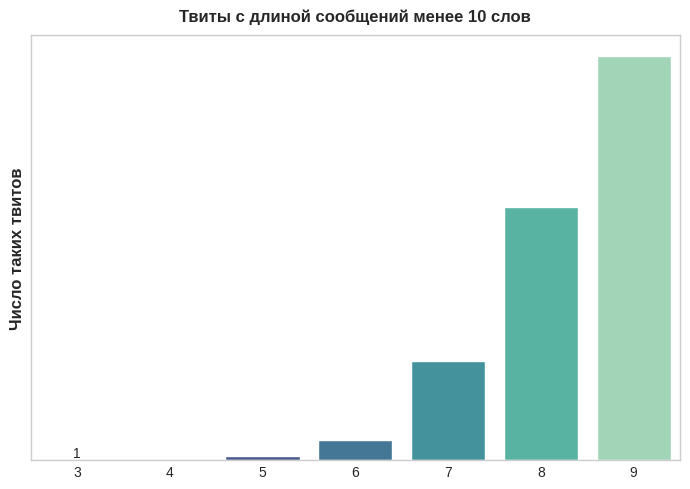

In [ ]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='text_len', data=df[df['text_len']<10], palette='mako')
plt.title('Твиты с длиной сообщений менее 10 слов')
plt.yticks([])
ax.bar_label(ax.containers[0])
plt.ylabel('Число таких твитов')
plt.xlabel('')
plt.show()

In [ ]:
print(f"Форма датасета: {df.shape}")

Форма датасета: (35774, 5)


In [ ]:
df = df[df['text_len'] > 4] # удаляем из обучающей выборки твиты короче 4 слов

In [ ]:
print(f"Форма датасета: {df.shape}")

Форма датасета: (35770, 5)


Токенизация

In [ ]:
# Будем использовать предобученный BERT-токенизатор.
tokenizer = BertTokenizerFast.from_pretrained('cointegrated/rubert-tiny2')

In [ ]:
# Применим токенизатор к "очищенным" данным:
token_lens = []

for txt in df['text_clean'].values:
    tokens = tokenizer.encode(txt)
    token_lens.append(len(tokens))

max_len=np.max(token_lens)

In [ ]:
print(f"Максимальная длина токенизированной последовательности: {max_len}")

Максимальная длина токенизированной последовательности: 903


Анализ колонки Category

In [ ]:
df['category'].value_counts()

,count
category,
autosport,3015
tennis,2929
hockey,2897
martial_arts,2885
football,2785
volleyball,2773
extreme,2758
winter_sport,2726
motosport,2720


In [ ]:
# закодируем категории цифрами
category_dict = {cat:i for i, cat in enumerate(df['category'].unique())}

category_dict

{'winter_sport': 0,
 'extreme': 1,
 'football': 2,
 'boardgames': 3,
 'hockey': 4,
 'esport': 5,
 'athletics': 6,
 'motosport': 7,
 'basketball': 8,
 'tennis': 9,
 'autosport': 10,
 'martial_arts': 11,
 'volleyball': 12}

In [ ]:
df['category'] = df['category'].map(category_dict)

In [ ]:
df.head(10)

,oid,category,text,text_clean,text_len
0,365271984,0,Волшебные фото Виктория Поплавская ЕвгенияМедв...,волшебные фото виктория поплавская евгениямедв...,6
1,503385563,1,Возвращение в подземелье Треша 33 Эйфория тупо...,возвращение в подземелье треша 33 эйфория тупо...,41
2,146016084,2,Лучшие чешские вратари – Доминик Доминатор Гаш...,лучшие чешские вратари – доминик доминатор гаш...,110
3,933865449,3,Rtokenoid Warhammer40k валрак решил нас подкор...,rtokenoid warhammer40k валрак решил нас подкор...,209
4,713550145,4,Шестеркин затаскивает Рейнджерс в финал Восточ...,шестеркин затаскивает рейнджерс в финал восточ...,382
5,780575952,3,Северные территории на границе королевства Нал...,северные территории на границе королевства нал...,40
6,741108447,4,Рашит Давыдов поделился деталями общения с гол...,рашит давыдов поделился деталями общения с гол...,72
7,642761184,5,Какой т3 игрок на данный момент перспективнее ...,какой т3 игрок на данный момент перспективнее ...,14
8,418053478,6,7 августа в Москве в Измайловском парке состои...,7 августа в москве в измайловском парке состои...,103
9,748701390,7,Ребята подскажите диску капец или нет Таких тр...,ребята подскажите диску капец или нет таких тр...,10


In [ ]:
df['category'].value_counts()

,count
category,
10,3015
9,2929
4,2897
11,2885
2,2785
12,2773
1,2758
0,2726
7,2720


In [ ]:
# С помощью метода RandomOverSampler, мы увеличим выборки для классов с меньшим числом образцов

# Создание экземпляра RandomOverSampler
ros = RandomOverSampler()

# Применение увеличения выборки к данным (X_resampled, y_resampled = ros.fit_resample(X, y))
train_x, train_y = ros.fit_resample(np.array(df['text_clean']).reshape(-1, 1), np.array(df['category']).reshape(-1, 1));

# Снова объединим выборки в DataFrame
train_os = pd.DataFrame(list(zip([x[0] for x in train_x], train_y)), columns = ['text_clean', 'category']);

In [ ]:
train_os['category'].value_counts()

,count
category,
0,3015
1,3015
2,3015
3,3015
4,3015
5,3015
6,3015
7,3015
8,3015


Обучающая, проверочная и тестовая выборки

In [ ]:
X = train_os['text_clean'].values
y = train_os['category'].values

In [ ]:
# тренировочная и промежуточная выборка
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed, shuffle=True)

# тестовая  и проверочная выборка
X_test, X_valid, y_test, y_valid = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed)

In [ ]:
# Закодируем метки с помощью метода One hot encoding

ohe = preprocessing.OneHotEncoder() # создаем экземпляр класса OneHotEncoder()

# Формируем кодированные OHE метки для тренировочной, проверочной и тестовой выборок
y_train = ohe.fit_transform(np.array(y_train).reshape(-1, 1)).toarray()
y_valid = ohe.fit_transform(np.array(y_valid).reshape(-1, 1)).toarray()
y_test = ohe.fit_transform(np.array(y_test).reshape(-1, 1)).toarray()

In [ ]:
print(f"Тренировочная выборка: {X_train.shape[0]}")
print(f"Проверочная выборка: {X_valid.shape[0]}")
print(f"Тестовая выборка: {X_test.shape[0]}")

Тренировочная выборка: 31356
Проверочная выборка: 3920
Тестовая выборка: 3919


### Классификация с помощью BERT

In [ ]:
def tokenize(data, max_len=128) :
    input_ids = []
    attention_masks = []
    for i in range(len(data)):
        encoded = tokenizer.encode_plus(
            data[i],
            add_special_tokens=True,
            max_length=max_len,
            truncation=True,
            padding='max_length',
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return np.array(input_ids), np.array(attention_masks)

In [ ]:
# Применим функцию токенизатора к наборам данным и получим соответствующие маски:
max_len = 256

train_input_ids, train_attention_masks = tokenize(X_train, max_len=max_len)
val_input_ids, val_attention_masks = tokenize(X_valid, max_len=max_len)
test_input_ids, test_attention_masks = tokenize(X_test, max_len=max_len)

In [ ]:
# Теперь мы можем импортировать предварительно обученную BERT модель из библиотеки Hugging face.

bert_model = TFBertModel.from_pretrained('cointegrated/rubert-tiny2') # префикс TF означает, что модель для TensorFlow

In [ ]:
# Соберем модель

def create_model(bert_model, max_len=128):

    # Параметры обучения
    opt = tf.keras.optimizers.legacy.Adam(learning_rate=1e-5, decay=1e-7) # оптимизатор - Adam
    loss = tf.keras.losses.CategoricalCrossentropy()                      # функция потерь - категориальная кросс-энтропия
    accuracy = tf.keras.metrics.CategoricalAccuracy()                     # метрика - категориальная точность

    input_ids = tf.keras.Input(shape=(max_len,), dtype='int32')         # вход для токенизированной последовательности
    attention_masks = tf.keras.Input(shape=(max_len,), dtype='int32')   # маска
    embeddings = bert_model([input_ids, attention_masks])[1]            # BERT-модель
    output = tf.keras.layers.Dense(len(CLASSES), activation="softmax")(embeddings) # полносвязный слой для классификации OHE (3 нейрона - 3 класса)
    model = tf.keras.models.Model(inputs = [input_ids, attention_masks], outputs = output)
    model.compile(opt, loss=loss, metrics=accuracy)

    return model

In [ ]:
model = create_model(bert_model, max_len=max_len)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 256)]                0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 256)]                0         []                            
                                                                                                  
 tf_bert_model (TFBertModel  multiple                     2919376   ['input_3[0][0]',             
 )                                                        8          'input_4[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 13)                   4069      ['tf_bert_model[1][1]'] 

In [ ]:
history_bert = model.fit([train_input_ids, train_attention_masks], y_train, validation_data=([val_input_ids, val_attention_masks], y_valid), epochs=17, batch_size=32)

Epoch 1/20
980/980 [==============================] - 167s 155ms/step - loss: 1.7574 - categorical_accuracy: 0.4804 - val_loss: 1.0716 - val_categorical_accuracy: 0.6814
Epoch 2/20
980/980 [==============================] - 150s 153ms/step - loss: 0.9441 - categorical_accuracy: 0.7236 - val_loss: 0.7952 - val_categorical_accuracy: 0.7673
Epoch 3/20
980/980 [==============================] - 150s 153ms/step - loss: 0.7258 - categorical_accuracy: 0.7867 - val_loss: 0.6863 - val_categorical_accuracy: 0.7952
Epoch 4/20
980/980 [==============================] - 150s 153ms/step - loss: 0.6001 - categorical_accuracy: 0.8245 - val_loss: 0.6208 - val_categorical_accuracy: 0.8209
Epoch 5/20
980/980 [==============================] - 150s 153ms/step - loss: 0.5104 - categorical_accuracy: 0.8509 - val_loss: 0.5796 - val_categorical_accuracy: 0.8347
Epoch 6/20
980/980 [==============================] - 150s 153ms/step - loss: 0.4349 - categorical_accuracy: 0.8732 - val_loss: 0.5526 - val_categoric

In [ ]:
# Запустим предсказание на тестовой выборке:
result_bert = model.predict([test_input_ids, test_attention_masks])

123/123 [==============================] - 9s 52ms/step


In [ ]:
def conf_matrix(y, y_pred, title):
    fig, ax = plt.subplots(figsize=(10,10))
    labels = CLASSES
    ax=sns.heatmap(confusion_matrix(y, y_pred), annot=True, cmap="Blues", fmt='g', cbar=False, annot_kws={"size":10})
    plt.title(title, fontsize=15)
    ax.xaxis.set_ticklabels(labels, fontsize=10)
    ax.yaxis.set_ticklabels(labels, fontsize=10)
    ax.set_ylabel('Тест', fontsize=15)
    ax.set_xlabel('Предсказание', fontsize=15)
    plt.show()

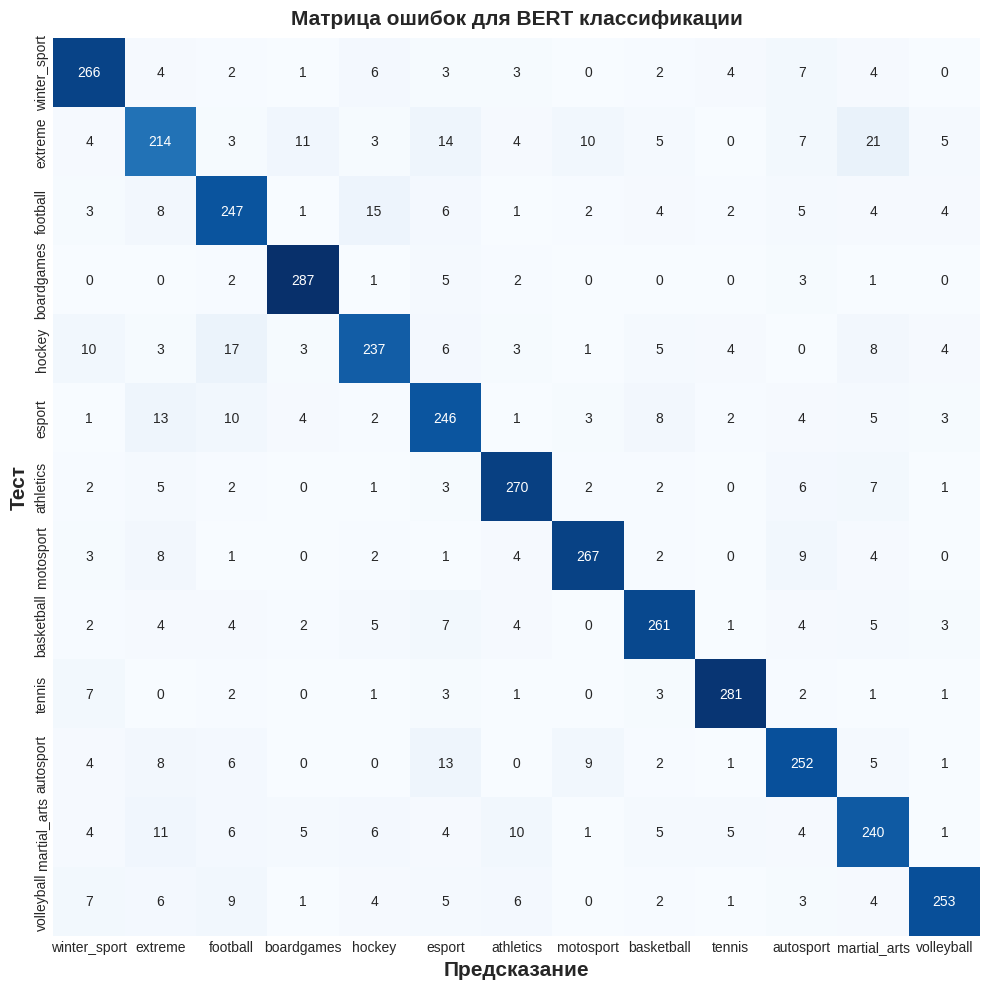

In [ ]:
# Возвращаем метку наиболее вероятного класса и строим матрицу ошибок:
y_pred_bert =  np.zeros_like(result_bert)
y_pred_bert[np.arange(len(y_pred_bert)), result_bert.argmax(1)] = 1

conf_matrix(y_test.argmax(1), y_pred_bert.argmax(1),'Матрица ошибок для BERT классификации')

In [ ]:
# Расчитаем метрики:
print('Расчет метрик для BERT классификатора:')
print()
print()
print(classification_report(y_test, y_pred_bert, target_names=CLASSES))

Расчет метрик для BERT классификатора:


              precision    recall  f1-score   support

winter_sport       0.85      0.88      0.87       302
     extreme       0.75      0.71      0.73       301
    football       0.79      0.82      0.81       302
  boardgames       0.91      0.95      0.93       301
      hockey       0.84      0.79      0.81       301
      esport       0.78      0.81      0.80       302
   athletics       0.87      0.90      0.89       301
   motosport       0.91      0.89      0.90       301
  basketball       0.87      0.86      0.87       302
      tennis       0.93      0.93      0.93       302
   autosport       0.82      0.84      0.83       301
martial_arts       0.78      0.79      0.79       302
  volleyball       0.92      0.84      0.88       301

   micro avg       0.85      0.85      0.85      3919
   macro avg       0.85      0.85      0.85      3919
weighted avg       0.85      0.85      0.85      3919
 samples avg       0.85      0.85      

### Тесты

In [ ]:
def get_prediction(num):
    print("Реальный порядковый номер класса:", y_test[num].argmax(0))
    print("Реальный класс:", CLASSES[y_test[num].argmax(0)])
    print("Текст:", X_test[num])

    pred = model.predict([test_input_ids[num].reshape(1, -1), test_attention_masks[num].reshape(1, -1)], verbose=0)

    print("\nПредсказанный класс:", CLASSES[np.argmax(pred)])

In [ ]:
i = 1
get_prediction(i)

Реальный порядковый номер класса: 6
Реальный класс: athletics
Текст: в любой непонятной ситуации иди на беговую тренировку и все встанет на свои места 33 главная цель тренировочного процесса избавиться от напряженности движений которая мешает двигаться вспомните как легко и непринужденно мы бегали в детстве не задумываясь о технике бега с взрослением и появлением в жизни стрессов движения стали скованнее а мышцы зажатыми это мешает получать удовольствие от бега прогрессировать избегать травм постепенное увеличение объемов общего километража тренировок и хорошая физическая подготовка сделают бег более свободным и расслабленным отличных беговых тренировок вам друзья 33 rtokenoid бег спорт зож забег забегрф легкаяатлетика мотивация фитнес

Предсказанный класс: athletics


In [ ]:
i = 2
get_prediction(i)

Реальный порядковый номер класса: 8
Реальный класс: basketball
Текст: джей ар смит нба закрыла мне путь в лигу в черном списке и другие игроки защитник джей ар смит уверен в том что нба не хочет видеть его в своих рядах 36 летний смит не играл в нба с 2020 года когда в составе лейкерс выиграл второй в карьере чемпионский перстень нба закрыла мне путь в лигу я на сто процентов уверен в этом любой может выйти и подтвердить вам это это факт в лиге 30 команд давайте оценим ребят в составах которые занимают позиции с четвертой по пятнадцатую просто с четвертой по пятнадцатую назовите мне человека который лучше меня несколько менеджеров связывались со мной интересовались почему я все еще не в лиге в черном списке и другие игроки такая же история с джо джонсоном джамалом кроуфордом ником янгом и айзейей томасом – заявил смит stokenoid

Предсказанный класс: basketball


In [ ]:
i = 3
get_prediction(i)

Реальный порядковый номер класса: 0
Реальный класс: winter_sport
Текст: васнецова миронова казакевич и резцова – наш состав на женскую эстафету в рупольдинге смотрите гонку в 16 30 мск трансляция

Предсказанный класс: winter_sport


In [ ]:
i = 4
get_prediction(i)

Реальный порядковый номер класса: 4
Реальный класс: hockey
Текст: защитник реактора олег травин прокомментировал драматичный матч с кузнецкими медведями 4 3 от мы проиграли третий период видимо очень сильно расслабились думали на одном коньке пройдемся поэтому такой результат был однако мы исправились и смогли выиграть наше сегодняшнее спасение чем то напомнило финал олимпиады 2018 года когда сборная россии также в меньшинстве спаслась да есть что то похожее мы работаем над этим на тренировках этот гол в меньшинстве полностью перевернул игру он дал нам почувствовать силы и как результат наша победа 33

Предсказанный класс: hockey


In [ ]:
i = 5
get_prediction(i)

Реальный порядковый номер класса: 8
Реальный класс: basketball
Текст: может дрилл встречу организовать в питере кто будет все кроме фанатов лекерс

Предсказанный класс: basketball
